In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import expon
from bayesian_dro.Bayesian_DRO_continuous import data_generation
from mis_dro.dataset import data_generation_outliers, data_generation_gamma
from bayesian_dro.Bayesian_DRO_continuous import EPSILON_SET

/tmp/dcs-tmp.u1604520/ipykernel_696712/2478035765.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
experiment_dir = "/dcs/pg23/u1604520/misdro/results_kdro/"
experiment_dir_bdro = "/dcs/pg23/u1604520/misdro/results_kdro/bdro/"
# results_df = pd.read_csv(experiment_dir / "results.csv", index_col="uuid")
#results_other_dgps_df = pd.read_csv(experiment_dir / "results_patrick.csv", index_col="uuid")
#results_df = pd.concat([results_other_dgps_df, results_gamma_df])
dfs = []
for dir in [experiment_dir, experiment_dir_bdro]:
    for epsilon in EPSILON_SET:
        if dir == experiment_dir:
            file_path = dir + f"kdro_cont_exp_N100_{epsilon}.csv" #f"kdro_cont_normal_N400_{epsilon}.csv"   #test_results_eps_{epsilon}.csv
        else:
            file_path = dir + f"kdro_cont_normal_N100_{epsilon}.csv"
        
        df = pd.read_csv(file_path)
        df['epsilon'] = epsilon
        if dir == experiment_dir:
            df['algorithm'] = 'mmd-dro'
        else:
            df['algorithm'] = 'bdro'
        dfs.append(df)
results_df = pd.concat(dfs, ignore_index=True)
# check the number of train/test observations is the same:
# assert len(results_df["num_observations"].unique()) == 1
# assert len(results_df["num_test_observations"].unique()) == 1
# num_observations = results_df["num_observations"]
# num_test_observations = results_df["num_test_observations"]
results_df

,replication,mean_cost,var_cost,solution,dgp_time,likelihood_time,posterior_time,solve_time,epsilon,algorithm
0,0,39.207928,391.317169,20.619350,0.000538,0.003733,66.436629,12.251990,0.001,mmd-dro
1,1,33.151214,1733.464453,12.893748,0.000925,0.003295,51.720873,11.906139,0.001,mmd-dro
2,2,34.855406,2289.871244,10.603209,0.000665,0.001934,36.700804,12.031332,0.001,mmd-dro
3,3,46.379430,2939.081026,13.917774,0.000665,0.001698,36.647923,12.050936,0.001,mmd-dro
4,4,38.551465,652.785529,19.816036,0.000632,0.002006,36.483648,12.059806,0.001,mmd-dro
...,...,...,...,...,...,...,...,...,...,...
3595,95,88.107677,389.557044,38.870000,0.000447,0.000546,0.000102,206.291872,3.000,bdro
3596,96,189.016347,578.769576,73.120000,0.000440,0.000562,0.000104,235.580932,3.000,bdro
3597,97,95.984518,379.030654,39.910000,0.000442,0.000557,0.000104,208.634747,3.000,bdro
3598,98,51.659852,1775.740988,21.140000,0.000441,0.000542,0.000111,202.260267,3.000,bdro


In [3]:
# results_df = results_df[results_df['epsilon'] < 0.2]

In [4]:
gb = results_df.groupby(by=["algorithm", "epsilon"])
df = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    "posterior_time": ["mean"],
    "solve_time": ["mean"],
    "solution": ["mean", "var"]
})
df

mean_cost                  var_cost posterior_time  \
                         mean          var         mean           mean   
algorithm epsilon                                                        
bdro      0.001     46.778913   218.072904  1244.578555       0.000106   
          0.002     47.221901   226.827771  1227.394242       0.000106   
          0.005     47.813531   247.652947  1201.847596       0.000106   
          0.010     48.682826   259.644103  1168.958636       0.000106   
          0.020     49.793220   277.252508  1123.074588       0.000106   
          0.050     52.036289   325.664386  1048.161816       0.000106   
          0.100     55.007385   429.462835   980.885118       0.000106   
          0.150     57.358041   514.357163   937.929406       0.000106   
          0.200     59.564831   612.893008   907.710262       0.000106   
          0.250     61.466580   689.828792   883.992083       0.000106   
          0.300     63.512796   770.443805   861.514861       0.000106   
          0.400     67.166462   952.837201   830.409502       0.000106   
          0.500     70.001981  1088.211121   807.014141       0.000106   
          1.000     81.317497  1519.199616   763.353942       0.000106   
          1.500     85.466367  1654.572049   760.629912       0.000106   
          2.000     96.984910  2015.629473   702.973601       0.000106   
          2.500     96.989460  2015.572356   702.958112       0.000106   
          3.000     96.989460  2015.572356   702.958112       0.000106   
mmd-dro   0.001     39.653097    98.447047  1689.817791      34.840296   
          0.002     39.691236    98.891310  1686.183075      34.840296   
          0.005     39.733392    97.164179  1669.833508      34.840296   
          0.010     39.837229    95.678946  1649.188100      34.840296   
          0.020     39.997344    95.152982  1605.188962      34.840296   
          0.050     40.730548    95.378932  1483.796219      34.840296   
          0.100     42.550015   100.976808  1279.580708      34.840296   
          0.150     45.234177   120.266280  1089.533412      34.840296   
          0.200     49.479972   160.028987   932.605467      34.840296   
          0.250     60.148959   459.777086   795.714950      34.840296   
          0.300     78.453587  1419.882241   737.655840      34.840296   
          0.400    106.116512  2615.436679   685.652604      34.840296   
          0.500    109.377792  2738.716482   683.467329      34.840296   
          1.000    111.009999  2814.171196   683.711790      34.840296   
          1.500    111.009999  2814.171202   683.711791      34.840296   
          2.000    111.009999  2814.171214   683.711790      34.840296   
          2.500    111.009999  2814.171196   683.711791      34.840296   
          3.000    111.009999  2814.171175   683.711790      34.840296   

                   solve_time   solution              
                         mean       mean         var  
algorithm epsilon                                     
bdro      0.001    206.369323  19.970800   49.429315  
          0.002    206.369323  20.207400   51.028985  
          0.005    206.369323  20.555800   53.905301  
          0.010    206.369323  21.044200   56.009994  
          0.020    206.369323  21.675400   58.464995  
          0.050    206.369323  22.917100   64.916627  
          0.100    206.369323  24.384700   77.672498  
          0.150    206.369323  25.507100   87.380219  
          0.200    206.369323  26.486900   98.839143  
          0.250    206.369323  27.332200  107.105654  
          0.300    206.369323  28.201700  115.809976  
          0.400    206.369323  29.705000  136.204490  
          0.500    206.369323  30.839300  151.245043  
          1.000    206.369323  35.112200  201.609795  
          1.500    206.369323  36.612700  217.426919  
          2.000    206.369323  40.905700  252.495372  
          2.500    206.369323  40.907400  252.485355  
          3.000    206.369323  40

In [5]:
def plot_dgp(df, dgp: str, axis, Nsamples):
    # get a dataframe for each posterior
    bayes_df = df.loc["bdro", :]
    # wll_df = df.loc[algorithm, dgp, :, "wll"]
    mmd_df = df.loc["mmd-dro", :]

    # # mean of variances + variance of means
    bayes_bootstrap_var = bayes_df["var_cost"]["mean"] + bayes_df["mean_cost"]["var"]
    # wll_bootstrap_var = wll_df["var_cost"]["mean"] + wll_df["mean_cost"]["var"]
    mmd_bootstrap_var = mmd_df["var_cost"]["mean"] + mmd_df["mean_cost"]["var"]

    # plot mean-variance trade-off
    axis.plot(bayes_bootstrap_var, bayes_df["mean_cost"]["mean"], marker='o', linestyle="solid", label="BDRO")
    # axis.plot(wll_bootstrap_var, wll_df["mean_cost"]["mean"], marker="x", linestyle="dashed", label="WLL-NPL")
    axis.plot(mmd_bootstrap_var, mmd_df["mean_cost"]["mean"], marker="v", linestyle="dotted", label="BAS-DRO (MMD-NPL)")

    # set title and label epsilon
    axis.set_title(f"DGP is {dgp}, {Nsamples} samples")
    axis.legend()
    axis.set_xlabel("out-of-sample variance")
    axis.set_ylabel("out-of-sample mean")
    for i, epsilon in enumerate(mmd_df.index.get_level_values("epsilon")):
        if i % 4 == 0:
            axis.text(bayes_bootstrap_var[epsilon], bayes_df["mean_cost"]["mean"][epsilon], epsilon, ha='left', va='bottom')
        if (i+2) % 4 == 0:
            axis.text(mmd_bootstrap_var[epsilon], mmd_df["mean_cost"]["mean"][epsilon], epsilon, ha='right', va='bottom')

# plot mean-variance trade-off for each DGP
# dgp_list = list(df.index.get_level_values("dgp").unique())
# nrows = int(np.ceil(len(dgp_list)/2.0))
# fig, axes = plt.subplots(nrows=nrows, ncols=2, sharex=False, sharey=False, figsize=(10,10))
# for i, dgp in enumerate(dgp_list):
#     row = int(np.floor(i / 2.0))
#     col = i % 2
#     plot_dgp(dgp, axes[row][col])

FileNotFoundError: [Errno 2] No such file or directory: '/dcs/pg23/u1604520/misdro/results_kdro/kdro_cont_exp_N400_0.001.csv'

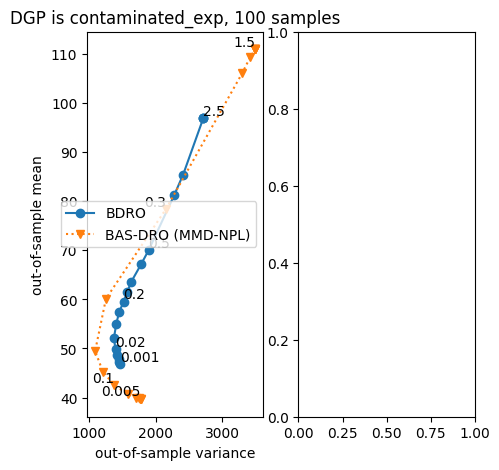

In [6]:
fig, axes = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=False, figsize=(5,5))
N_values = [100, 400]
for i, N in enumerate(N_values):
    dfs = []
    for dir in [experiment_dir, experiment_dir_bdro]:
        for epsilon in EPSILON_SET:
            if dir == experiment_dir:
                file_path = dir + f"kdro_cont_exp_N{N}_{epsilon}.csv" #f"kdro_cont_normal_N400_{epsilon}.csv"   #test_results_eps_{epsilon}.csv
            else:
                file_path = dir + f"kdro_cont_normal_N{N}_{epsilon}.csv"   # same exp just wrong file name
        
            df = pd.read_csv(file_path)
            df['epsilon'] = epsilon
            if dir == experiment_dir:
                df['algorithm'] = 'mmd-dro'
            else:
                df['algorithm'] = 'bdro'
            dfs.append(df)
    results_df = pd.concat(dfs, ignore_index=True)
    gb = results_df.groupby(by=["algorithm", "epsilon"])
    df = gb.agg({
        "mean_cost": ["mean", "var"],
        "var_cost": ["mean"],
        "posterior_time": ["mean"],
        "solve_time": ["mean"],
        "solution": ["mean", "var"]
    })
    plot_dgp(df, 'contaminated_exp', axes[i], N)
plt.show()

In [7]:
from scipy.stats import truncnorm
b = 8
h = 3
L = 100

DGP_MEAN_TRUNCATED_NORMAL = 10
DGP_STD_TRUNCATED_NORMAL = 10

NUM_OBSERVATIONS = 20
sol_true = truncnorm.ppf(
        (b - 0) / (h + b), a=-DGP_MEAN_TRUNCATED_NORMAL / DGP_STD_TRUNCATED_NORMAL, b=np.inf, loc=DGP_MEAN_TRUNCATED_NORMAL, scale=DGP_STD_TRUNCATED_NORMAL
    )

In [8]:
sol_true

17.406341169581744

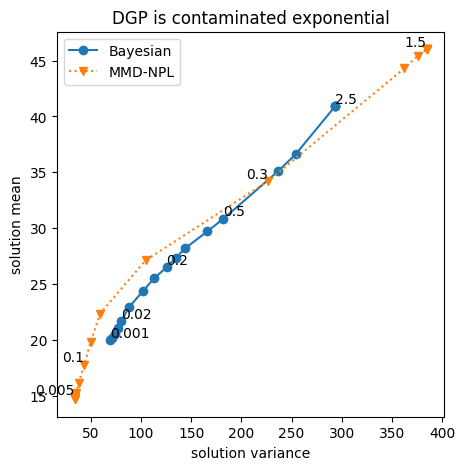

In [9]:
fig, ax = plt.subplots(nrows=1, ncols=1, sharex=False, sharey=False, figsize=(5,5))
bayes_df = df.loc["bdro", :]
mmd_df = df.loc["mmd-dro", :]

bayes_bootstrap_var = bayes_df["solution"]["mean"] + bayes_df["solution"]["var"]
mmd_bootstrap_var = mmd_df["solution"]["mean"] + mmd_df["solution"]["var"]

# plot mean-variance trade-off
ax.plot(bayes_bootstrap_var, bayes_df["solution"]["mean"], marker='o', linestyle="solid", label="Bayesian")
    # axis.plot(wll_bootstrap_var, wll_df["mean_cost"]["mean"], marker="x", linestyle="dashed", label="WLL-NPL")
ax.plot(mmd_bootstrap_var, mmd_df["solution"]["mean"], marker="v", linestyle="dotted", label="MMD-NPL")

# set title and label epsilon
ax.set_title("DGP is contaminated exponential")
ax.legend()
ax.set_xlabel("solution variance")
ax.set_ylabel("solution mean")
for i, epsilon in enumerate(mmd_df.index.get_level_values("epsilon")):
    if i % 4 == 0:
        ax.text(bayes_bootstrap_var[epsilon], bayes_df["solution"]["mean"][epsilon], epsilon, ha='left', va='bottom')
    if (i+2) % 4 == 0:
        ax.text(mmd_bootstrap_var[epsilon], mmd_df["solution"]["mean"][epsilon], epsilon, ha='right', va='bottom')

Number of certifying points 

In [21]:
n_cert_values = [5, 20, 100]
experiment_dir = "/dcs/pg23/u1604520/misdro/results_kdro/ncert/"
dfs = []
for ncert in n_cert_values:
    for epsilon in EPSILON_SET:
        file_path = experiment_dir + f"kdro_cont_exp_N25_ncert_{ncert}_{epsilon}.csv" 
        df = pd.read_csv(file_path)
        df['epsilon'] = epsilon
        df['ncert'] = ncert
        # df['algorithm'] = 'mmd-dro'
        dfs.append(df)
results_df = pd.concat(dfs, ignore_index=True)
gb = results_df.groupby(by=["epsilon", 'ncert'])
df = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    "posterior_time": ["mean"],
    "solve_time": ["mean"],
    "solution": ["mean", "var"]
})
df

mean_cost                  var_cost posterior_time solve_time  \
                    mean          var         mean           mean       mean   
epsilon ncert                                                                  
0.001   5      41.003834   117.784595  1684.199796      32.541000   2.560638   
        20     41.238288   119.066943  1659.759387      32.278920   3.545263   
        100    41.318634   121.590004  1664.658881      32.801849  12.112839   
0.002   5      41.087965   117.306235  1672.867524      32.541000   2.560638   
        20     41.341995   121.610721  1656.832544      32.278920   3.545263   
        100    41.253841   119.852579  1659.091641      32.801849  12.112839   
0.005   5      41.192305   118.274521  1667.173785      32.541000   2.560638   
        20     41.422357   123.410382  1648.386198      32.278920   3.545263   
        100    41.336741   123.153104  1646.557138      32.801849  12.112839   
0.010   5      41.315094   120.924640  1651.155711      32.541000   2.560638   
        20     41.469058   123.949111  1633.622204      32.278920   3.545263   
        100    41.490302   125.408508  1627.286672      32.801849  12.112839   
0.020   5      41.714913   129.062359  1616.897580      32.541000   2.560638   
        20     41.655643   126.858609  1602.229897      32.278920   3.545263   
        100    41.742262   129.800215  1597.677647      32.801849  12.112839   
0.050   5      42.559821   144.225159  1519.930139      32.541000   2.560638   
        20     42.569369   141.069328  1520.909913      32.278920   3.545263   
        100    42.565052   144.751434  1513.241599      32.801849  12.112839   
0.100   5      44.437862   172.916281  1360.640872      32.541000   2.560638   
        20     44.121180   167.007537  1369.685444      32.278920   3.545263   
        100    44.154849   172.136849  1378.075904      32.801849  12.112839   
0.150   5      46.485514   221.810500  1242.751313      32.541000   2.560638   
        20     46.236259   211.297205  1244.325284      32.278920   3.545263   
        100    46.178371   213.678389  1256.521160      32.801849  12.112839   
0.200   5      50.372133   359.161230  1138.652296      32.541000   2.560638   
        20     48.823084   281.847149  1140.893070      32.278920   3.545263   
        100    48.633531   276.149477  1148.505206      32.801849  12.112839   
0.250   5      56.224584   621.433110  1022.402205      32.541000   2.560638   
        20     53.573467   478.986419  1046.847907      32.278920   3.545263   
        100    53.191598   450.281700  1045.892101      32.801849  12.112839   
0.300   5      69.199087  1480.577010   928.791549      32.541000   2.560638   
        20     65.210128  1096.601938   938.451080      32.278920   3.545263   
        100    62.760862   928.822934   934.661291      32.801849  12.112839   
0.400   5      77.222372  2028.784376   863.998834      32.541000   2.560638   
        20     76.191567  1937.636351   865.852057      32.278920   3.545263   
        100    75.465720  1837.984410   866.378494      32.801849  12.112839   
0.500   5      78.577871  2131.803885   855.303811      32.541000   2.560638   
        20     78.357900  2115.090425   857.421259      32.278920   3.545263   
        100    78.448960  2131.977418   858.489356      32.801849  12.112839   
1.000   5      78.761449  2179.258428   866.712358      32.541000   2.560638   
        20     78.761449  2179.258618   866.712359      32.278920   3.545263   
        100    78.761450  2179.258606   866.712360      32.801849  12.112839   
1.500   5      78.761444  2179.257768   866.712356      32.541000   2.560638   
        20     78.761449  2179.258621   866.712358      32.278920   3.545263   
        100    78.761450  2179.258626   866.712357      32.801849  12.112839   
2.000   5      78.761449  2179.258561   866.712359      32.541000   2.560638   
        20     78.761449  2179.258609   866.712357      32.278920   3.545263   
        100    

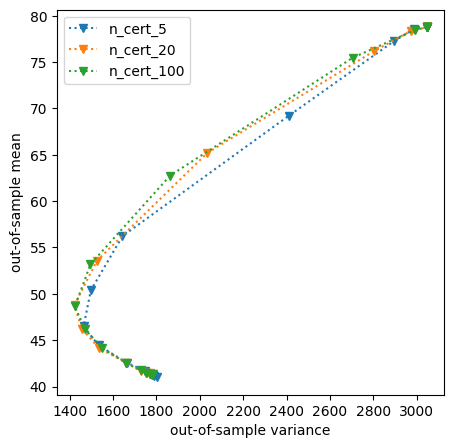

In [22]:
fig, axis = plt.subplots(nrows=1, ncols=1, sharex=False, sharey=False, figsize=(5,5))
for ncert in n_cert_values:
   dfn = df.xs(ncert, level='ncert')
   var = dfn["var_cost"]["mean"] + dfn["mean_cost"]["var"]
   axis.plot(var, dfn["mean_cost"]["mean"], marker="v", linestyle="dotted", label=f"n_cert_{ncert}")
axis.legend()
axis.set_xlabel("out-of-sample variance")
axis.set_ylabel("out-of-sample mean")

plt.show()